# 🧠 CNN Pipeline — Acne Level Classification

**Dataset: NNEW (Acne Level Dataset)**

```
filename   class_label   count
```
| Kolom | Keterangan |
|---|---|
| `filename` | Nama file gambar |
| `class_label` | Kelas Keparahan: 0, 1, 2, 3 |
| `count` | Tingkat Keparahan dalam gambar |

---
### Alur Pipeline
1. ⚙️ Konfigurasi & Import
2. 📂 Load & Parse Data
3. 📊 Eksplorasi Data (EDA)
4. 🔄 Persiapan Dataset (Generator)
5. 🏗️ Bangun Model CNN
6. 🚀 Training
7. 📈 Evaluasi & Visualisasi

## ⚙️ 1. Konfigurasi & Import Library

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU tersedia       : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.15.0
GPU tersedia       : False


In [ ]:
# ──────────────────────────────────────────────────────────────
# KONFIGURASI UTAMA — Sesuaikan sebelum menjalankan notebook
# ──────────────────────────────────────────────────────────────
CONFIG = {
    # Ukuran gambar setelah resize
    "img_size"      : (128, 128),
    "batch_size"    : 32,
    "epochs"        : 50,
    "num_classes"   : 4,          # Level 0, 1, 2, 3
    "learning_rate" : 1e-3,

    # ⚠️ Ganti path ini ke folder gambar Anda
    "data_dir"      : "Classification/JPEGImages",

    "train_files"   : [
        "Classification/NNEW_trainval_1.txt",
        "Classification/NNEW_trainval_0.txt",
        "Classification/NNEW_trainval_2.txt",
        "Classification/NNEW_trainval_3.txt",
        "Classification/NNEW_trainval_4.txt",
    ],
    "test_files"    : [
        "Classification/NNEW_test_0.txt",
        "Classification/NNEW_test_1.txt",
        "Classification/NNEW_test_2.txt",
        "Classification/NNEW_test_3.txt",
        "Classification/NNEW_test_4.txt",
    ],
    "class_names"   : ["Level 0", "Level 1", "Level 2", "Level 3"],
    "seed"          : 42,
}

tf.random.set_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print("✅ Konfigurasi berhasil dimuat")
print(f"   Image size  : {CONFIG['img_size']}")
print(f"   Batch size  : {CONFIG['batch_size']}")
print(f"   Epochs      : {CONFIG['epochs']}")
print(f"   Num classes : {CONFIG['num_classes']}")

✅ Konfigurasi berhasil dimuat
   Image size  : (128, 128)
   Batch size  : 32
   Epochs      : 50
   Num classes : 4


---
## 📂 2. Load & Parse Data

Membaca semua file `.txt` (train dan test) dan mengonversinya menjadi DataFrame.

In [10]:
def parse_txt_files(file_list, base_dir=""):
    """
    Membaca daftar file .txt dan mengembalikan DataFrame.
    
    Parameters
    ----------
    file_list : list[str]  — path ke file .txt
    base_dir  : str        — folder gambar (akan di-prefix ke filename)
    
    Returns
    -------
    pd.DataFrame dengan kolom: filename, label, count
    """
    records = []
    for fpath in file_list:
        if not os.path.exists(fpath):
            print(f"  ⚠️  File tidak ditemukan: {fpath}")
            continue
        with open(fpath, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    fname  = parts[0]
                    label  = int(parts[1])
                    count  = int(parts[2])
                    full_path = os.path.join(base_dir, fname) if base_dir else fname
                    records.append({
                        "filename" : full_path,
                        "label"    : label,
                        "count"    : count
                    })
    return pd.DataFrame(records)

In [11]:
df_train = parse_txt_files(CONFIG["train_files"])
df_test  = parse_txt_files(CONFIG["test_files"])

print(f"{'='*50}")
print(f"Total sampel training  : {len(df_train):,}")
print(f"Total sampel testing   : {len(df_test):,}")
print(f"{'='*50}")
print("\nPreview df_train:")
df_train.head(8)

Total sampel training  : 5,825
Total sampel testing   : 1,460

Preview df_train:


,filename,label,count
0,levle0_0.jpg,0,3
1,levle0_1.jpg,0,3
2,levle0_100.jpg,0,2
3,levle0_101.jpg,0,1
4,levle0_102.jpg,0,3
5,levle0_103.jpg,0,2
6,levle0_104.jpg,0,1
7,levle0_105.jpg,0,1


In [12]:
print("Distribusi label — Train:")
print(df_train["label"].value_counts().sort_index().rename(index={i: CONFIG["class_names"][i] for i in range(4)}))
print("\nDistribusi label — Test:")
print(df_test["label"].value_counts().sort_index().rename(index={i: CONFIG["class_names"][i] for i in range(4)}))
print("\nStatistik kolom 'count' (Train):")
df_train.groupby("label")["count"].describe().rename(index={i: CONFIG["class_names"][i] for i in range(4)})

Distribusi label — Train:
label
Level 0    2050
Level 1    2530
Level 2     730
Level 3     515
Name: count, dtype: int64

Distribusi label — Test:
label
Level 0    515
Level 1    635
Level 2    180
Level 3    130
Name: count, dtype: int64

Statistik kolom 'count' (Train):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Level 0,2050.0,2.103902,1.095906,1.0,1.0,2.0,3.0,5.0
Level 1,2530.0,8.958498,2.992718,6.0,7.0,8.0,10.0,20.0
Level 2,730.0,26.071233,5.219239,21.0,21.0,25.0,29.0,42.0
Level 3,515.0,57.699029,4.390995,51.0,54.0,58.0,62.0,65.0


---
## 📊 3. Eksplorasi Data (EDA)

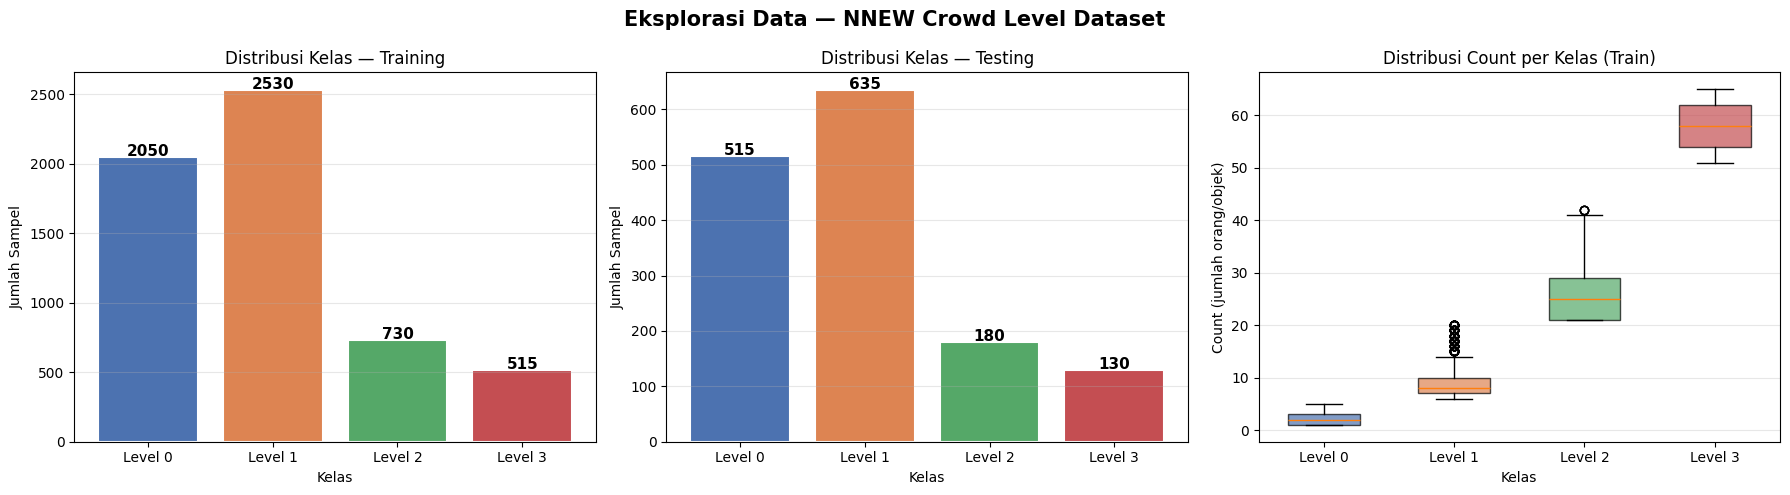

✅ Plot EDA disimpan: eda_visualization.png


In [ ]:
colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
class_names = CONFIG["class_names"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Eksplorasi Data — NNEW Acne Level Dataset", fontsize=15, fontweight="bold")

# ── Plot 1: Distribusi kelas train ──
counts_train = df_train["label"].value_counts().sort_index()
bars = axes[0].bar(class_names, counts_train.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribusi Kelas — Training", fontsize=12)
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")
for bar, v in zip(bars, counts_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 8,
                 str(v), ha="center", fontweight="bold", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# ── Plot 2: Distribusi kelas test ──
counts_test = df_test["label"].value_counts().sort_index()
bars2 = axes[1].bar(class_names, counts_test.values, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Distribusi Kelas — Testing", fontsize=12)
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Sampel")
for bar, v in zip(bars2, counts_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 2,
                 str(v), ha="center", fontweight="bold", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

# ── Plot 3: Boxplot count per kelas ──
data_per_class = [df_train[df_train["label"] == i]["count"].values for i in range(4)]
bp = axes[2].boxplot(data_per_class, labels=class_names, patch_artist=True, widths=0.55)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("Distribusi Count per Kelas (Train)", fontsize=12)
axes[2].set_xlabel("Kelas")
axes[2].set_ylabel("Count (jumlah orang/objek)")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("eda_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot EDA disimpan: eda_visualization.png")

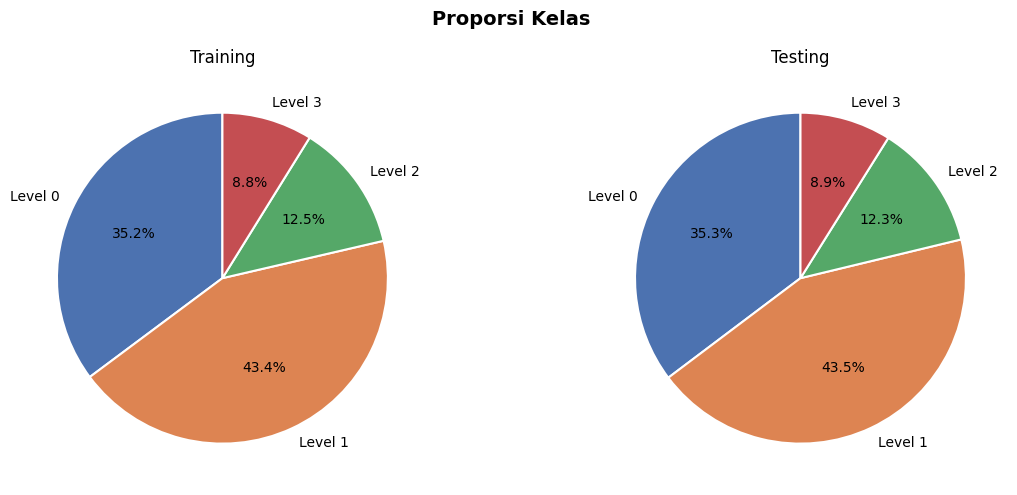

In [14]:
# Pie chart proporsi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Proporsi Kelas", fontsize=14, fontweight="bold")

for ax, df, title in zip(axes, [df_train, df_test], ["Training", "Testing"]):
    counts = df["label"].value_counts().sort_index()
    ax.pie(counts.values, labels=class_names, colors=colors,
           autopct="%1.1f%%", startangle=90,
           wedgeprops=dict(edgecolor="white", linewidth=1.5))
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

---
## 🔄 4. Persiapan Dataset (tf.data Pipeline)

Pipeline otomatis mendeteksi apakah folder gambar tersedia:
- **Tersedia** → membaca gambar nyata dari disk dengan augmentasi
- **Tidak tersedia** → menggunakan gambar sintetis untuk demo

In [15]:
def build_real_dataset(df, data_dir, img_size, batch_size, augment=False, shuffle=True):
    """Dataset dari gambar nyata di disk."""
    IMG_H, IMG_W = img_size

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_H, IMG_W])
        img = img / 255.0   # Normalisasi ke [0, 1]
        return img, label

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, label

    paths  = [os.path.join(data_dir, fn) for fn in df["filename"]]
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=CONFIG["seed"])
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_dummy_dataset(df, img_size, batch_size, augment=False, shuffle=True):
    """
    Dataset sintetis: setiap kelas punya warna dominan berbeda
    sehingga model masih bisa belajar pola sederhana.
    """
    IMG_H, IMG_W = img_size
    labels = df["label"].values
    N = len(labels)

    base_colors = np.array([
        [0.2, 0.4, 0.8],  # Level 0 – biru
        [0.3, 0.7, 0.3],  # Level 1 – hijau
        [0.8, 0.5, 0.2],  # Level 2 – oranye
        [0.7, 0.2, 0.3],  # Level 3 – merah
    ])

    rng  = np.random.RandomState(CONFIG["seed"])
    imgs = np.zeros((N, IMG_H, IMG_W, 3), dtype=np.float32)
    for i, lbl in enumerate(labels):
        noise   = rng.normal(0, 0.1, (IMG_H, IMG_W, 3)).astype(np.float32)
        imgs[i] = np.clip(base_colors[lbl] + noise, 0, 1)

    ds = tf.data.Dataset.from_tensor_slices((imgs, labels.astype(np.int32)))
    if shuffle:
        ds = ds.shuffle(N, seed=CONFIG["seed"])
    if augment:
        def aug(img, lbl):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.1)
            return tf.clip_by_value(img, 0, 1), lbl
        ds = ds.map(aug)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [16]:
# Cek apakah gambar tersedia
def images_available(df, data_dir):
    sample = df["filename"].iloc[0]
    return os.path.exists(os.path.join(data_dir, sample))

USE_REAL = images_available(df_train, CONFIG["data_dir"])

if USE_REAL:
    print(f"✅ Gambar ditemukan di '{CONFIG['data_dir']}' → menggunakan DATASET NYATA")
    train_ds = build_real_dataset(
        df_train, CONFIG["data_dir"], CONFIG["img_size"],
        CONFIG["batch_size"], augment=True, shuffle=True
    )
    test_ds = build_real_dataset(
        df_test, CONFIG["data_dir"], CONFIG["img_size"],
        CONFIG["batch_size"], augment=False, shuffle=False
    )
else:
    print("⚠️  Gambar tidak ditemukan → menggunakan DATASET DUMMY (demo)")
    print(f"   Pastikan folder gambar ada di: {CONFIG['data_dir']}")
    train_ds = build_dummy_dataset(
        df_train, CONFIG["img_size"], CONFIG["batch_size"],
        augment=True, shuffle=True
    )
    test_ds = build_dummy_dataset(
        df_test, CONFIG["img_size"], CONFIG["batch_size"],
        augment=False, shuffle=False
    )

# Tampilkan info batch pertama
for imgs, labels in train_ds.take(1):
    print(f"\nShape batch gambar : {imgs.shape}")
    print(f"Shape batch label  : {labels.shape}")
    print(f"Range pixel        : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]")

✅ Gambar ditemukan di './Classification/JPEGImages' → menggunakan DATASET NYATA

Shape batch gambar : (32, 128, 128, 3)
Shape batch label  : (32,)
Range pixel        : [0.000, 1.000]


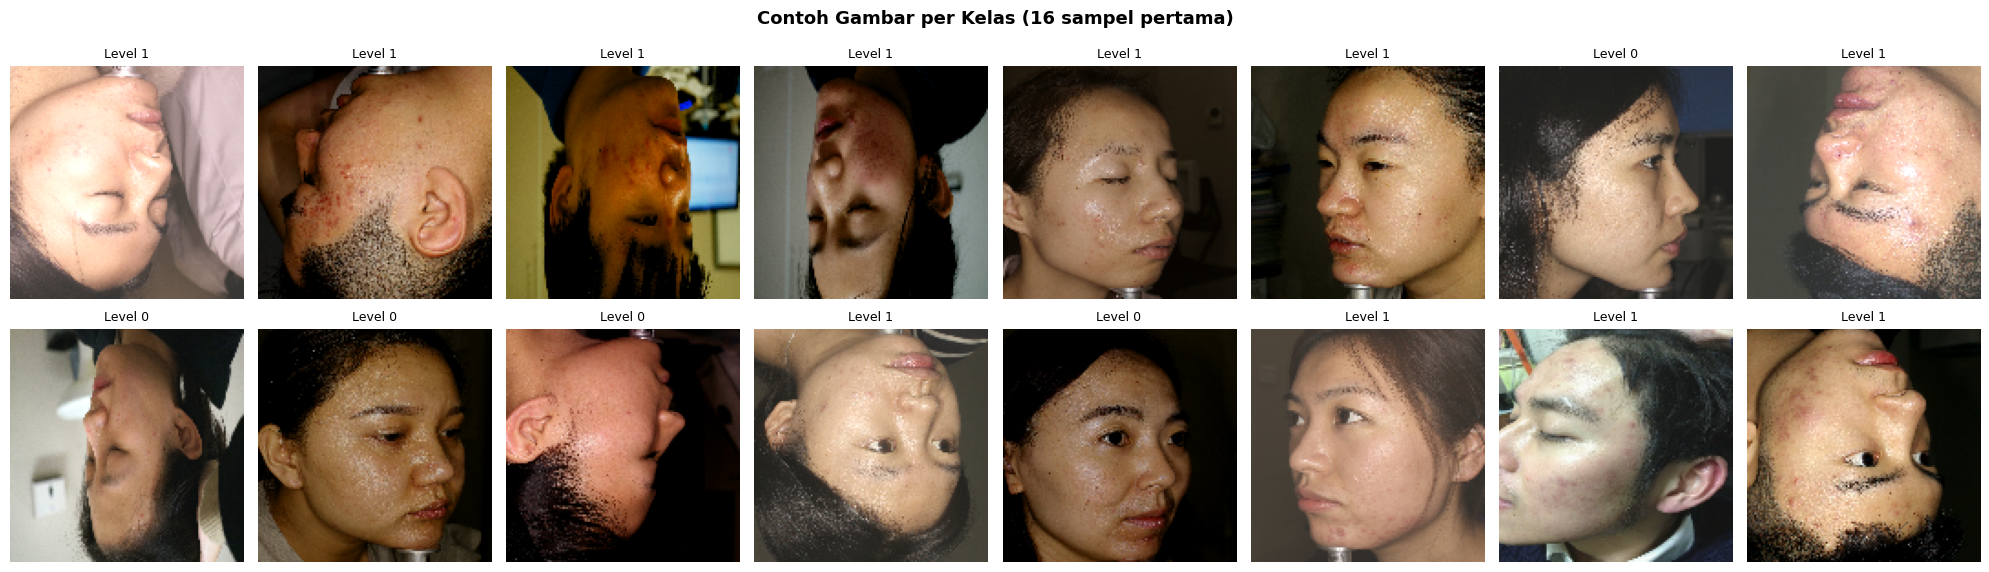

In [17]:
# Tampilkan contoh gambar dari setiap kelas
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Contoh Gambar per Kelas (16 sampel pertama)", fontsize=13, fontweight="bold")

sample_imgs, sample_labels = next(iter(train_ds))
sample_imgs   = sample_imgs.numpy()
sample_labels = sample_labels.numpy()

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.set_title(CONFIG["class_names"][sample_labels[i]], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## 🏗️ 5. Membangun Model CNN

### Arsitektur

```
Input (128×128×3)
│
├─ Blok 1: Conv2D(32) × 2 → BN → MaxPool → Dropout(0.25)
├─ Blok 2: Conv2D(64) × 2 → BN → MaxPool → Dropout(0.25)
├─ Blok 3: Conv2D(128) × 2 → BN → MaxPool → Dropout(0.30)
├─ Blok 4: Conv2D(256) × 1 → BN → MaxPool → Dropout(0.30)
│
├─ GlobalAveragePooling2D
├─ Dense(256) → BN → Dropout(0.50)
├─ Dense(128) → Dropout(0.40)
└─ Dense(4, softmax)  ← Output
```

In [ ]:
def build_cnn(input_shape, num_classes):
    """
    CNN kustom untuk klasifikasi Acne level.
    4 blok konvolusi + BatchNorm + MaxPool + Dropout.
    """
    inputs = keras.Input(shape=input_shape, name="input_image")

    # ── Blok Konvolusi 1 ──────────────────────────
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)        # Output: 64×64×32

    # ── Blok Konvolusi 2 ──────────────────────────
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)        # Output: 32×32×64

    # ── Blok Konvolusi 3 ──────────────────────────
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)        # Output: 16×16×128

    # ── Blok Konvolusi 4 ──────────────────────────
    x = layers.Conv2D(256, (3,3), padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)        # Output: 8×8×256

    # ── Classifier Head ────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)        # 256
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return keras.Model(inputs, outputs, name="AcneLevel_CNN")


input_shape = CONFIG["img_size"] + (3,)   # (128, 128, 3)
model = build_cnn(input_shape, CONFIG["num_classes"])
model.summary()



Model: "CrowdLevel_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 128, 128, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)   

In [19]:
optimizer = keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"])

model.compile(
    optimizer = optimizer,
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)

print("✅ Model berhasil di-compile")
print(f"   Total parameter : {model.count_params():,}")

✅ Model berhasil di-compile
   Total parameter : 685,220


### (Opsional) Transfer Learning — MobileNetV2

Jika dataset kecil atau akurasi kurang memuaskan, gunakan backbone pretrained.

In [ ]:
# ── Uncomment untuk menggunakan MobileNetV2 ──

# def build_mobilenet(input_shape, num_classes):
#     base = keras.applications.MobileNetV2(
#         input_shape=input_shape, include_top=False, weights="imagenet"
#     )
#     base.trainable = False    # Freeze backbone
#
#     inputs = keras.Input(shape=input_shape)
#     x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
#     x = base(x, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(128, activation="relu")(x)
#     x = layers.Dropout(0.4)(x)
#     outputs = layers.Dense(num_classes, activation="softmax")(x)
#     return keras.Model(inputs, outputs, name="MobileNetV2_AcneLevel")
#
# model = build_mobilenet(input_shape, CONFIG["num_classes"])
# model.compile(
#     optimizer=keras.optimizers.Adam(CONFIG["learning_rate"]),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )
# model.summary()

print("(Transfer learning tersedia, uncomment kode di atas untuk menggunakan)")

(Transfer learning tersedia, uncomment kode di atas untuk menggunakan)


---
## 🚀 6. Training Model

In [21]:
callbacks = [
    # Hentikan training jika val_loss tidak membaik selama 10 epoch
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Kurangi learning rate jika val_loss stagnan 5 epoch
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Simpan model terbaik berdasarkan val_accuracy
    ModelCheckpoint(
        filepath="best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
]

print("✅ Callbacks siap:")
print("   • EarlyStopping  (patience=10)")
print("   • ReduceLROnPlateau (patience=5, factor=0.5)")
print("   • ModelCheckpoint → best_model.h5")

✅ Callbacks siap:
   • EarlyStopping  (patience=10)
   • ReduceLROnPlateau (patience=5, factor=0.5)
   • ModelCheckpoint → best_model.h5


In [22]:
print("🚀 Mulai Training...")
print(f"   Epochs     : {CONFIG['epochs']}")
print(f"   Batch size : {CONFIG['batch_size']}")
print()

history = model.fit(
    train_ds,
    epochs          = CONFIG["epochs"],
    validation_data = test_ds,
    callbacks       = callbacks,
    verbose         = 1
)

print("\n✅ Training selesai!")

🚀 Mulai Training...
   Epochs     : 50
   Batch size : 32

Epoch 1/50


183/183 [==============================] - ETA: 0s - loss: 1.6057 - accuracy: 0.3904
Epoch 1: val_accuracy improved from -inf to 0.16507, saving model to best_model.h5
183/183 [==============================] - 187s 994ms/step - loss: 1.6057 - accuracy: 0.3904 - val_loss: 1.5618 - val_accuracy: 0.1651 - lr: 0.0010
Epoch 2/50
183/183 [==============================] - ETA: 0s - loss: 1.3189 - accuracy: 0.4167
Epoch 2: val_accuracy improved from 0.16507 to 0.39795, saving model to best_model.h5
183/183 [==============================] - 191s 1s/step - loss: 1.3189 - accuracy: 0.4167 - val_loss: 1.2409 - val_accuracy: 0.3979 - lr: 0.0010
Epoch 3/50
182/183 [============================>.] - ETA: 0s - loss: 1.2447 - accuracy: 0.4251
Epoch 3: val_accuracy did not improve from 0.39795
183/183 [==============================] - 178s 970ms/step - loss: 1.2447 - accuracy: 0.4252 - val_loss: 1.4139 - val_accuracy: 0.3678 - l

---
## 📈 7. Evaluasi & Visualisasi

In [23]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("=" * 40)
print("  HASIL EVALUASI")
print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 40)

  HASIL EVALUASI
  Test Loss     : 0.2435
  Test Accuracy : 0.9322  (93.22%)


In [24]:
# Kumpulkan prediksi & ground truth
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

print("Classification Report:")
print("─" * 55)
print(classification_report(y_true, y_pred, target_names=CONFIG["class_names"]))

Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Level 0       0.95      0.97      0.96       515
     Level 1       0.97      0.91      0.93       635
     Level 2       0.79      0.91      0.85       180
     Level 3       0.92      0.95      0.93       130

    accuracy                           0.93      1460
   macro avg       0.91      0.93      0.92      1460
weighted avg       0.94      0.93      0.93      1460



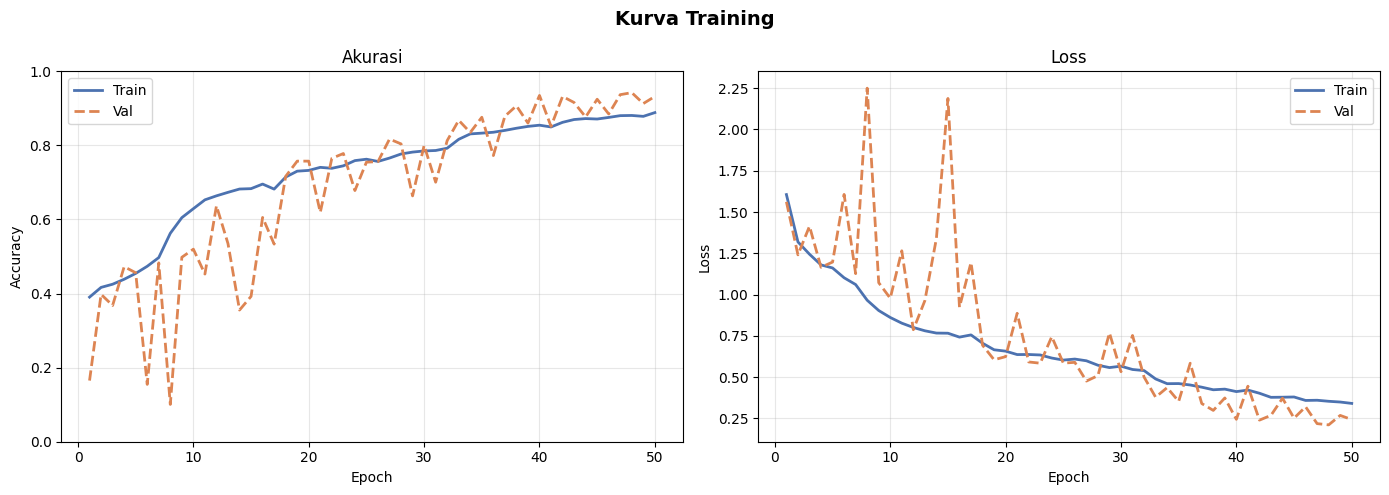

✅ Disimpan: training_history.png


In [ ]:
# ── Grafik Akurasi & Loss ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kurva Training", fontsize=14, fontweight="bold")

ep = range(1, len(history.history["accuracy"]) + 1)

axes[0].plot(ep, history.history["accuracy"],     label="Train", color="#4C72B0", lw=2)
axes[0].plot(ep, history.history["val_accuracy"], label="Val",   color="#DD8452", lw=2, ls="--")
axes[0].set_title("Akurasi")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(ep, history.history["loss"],     label="Train", color="#4C72B0", lw=2)
axes[1].plot(ep, history.history["val_loss"], label="Val",   color="#DD8452", lw=2, ls="--")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("output/training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan: training_history.png")

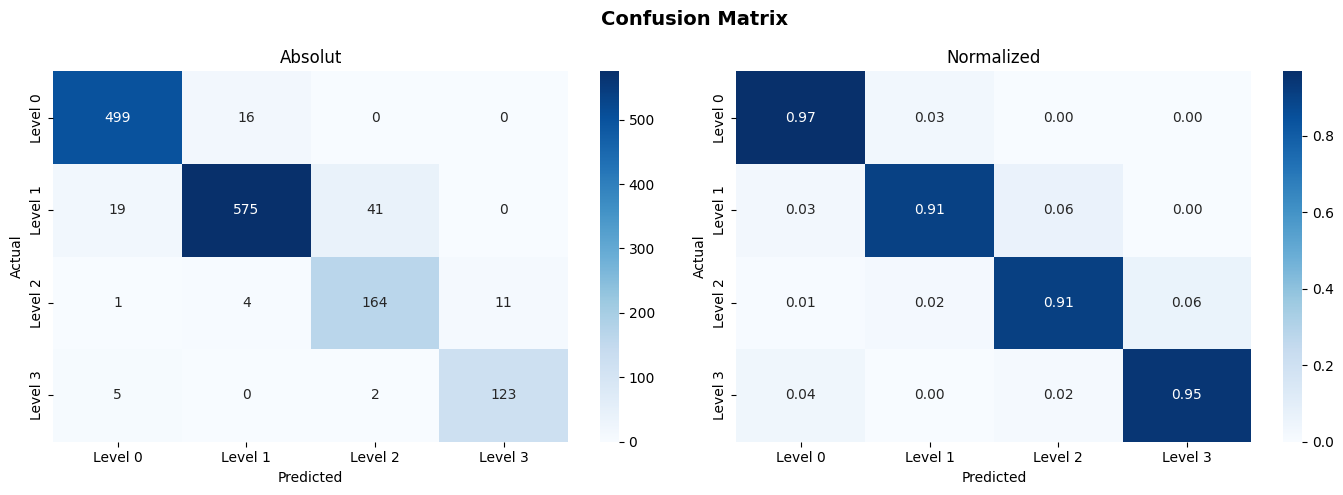

✅ Disimpan: confusion_matrix.png


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix", fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[0])
axes[0].set_title("Absolut")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[1])
axes[1].set_title("Normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("output/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Disimpan: confusion_matrix.png")

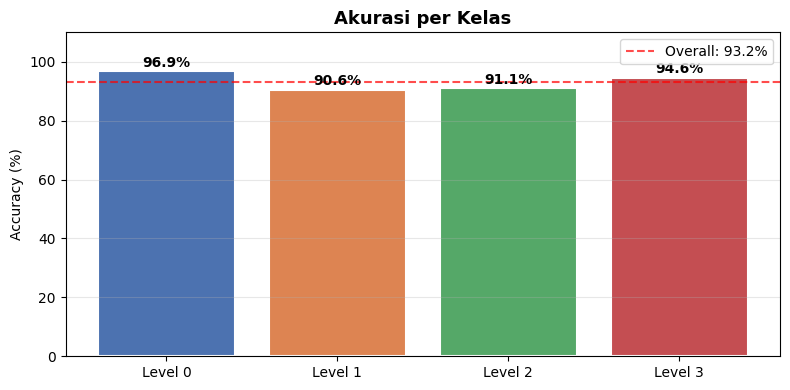

In [27]:
# ── Akurasi per Kelas ─────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CONFIG["class_names"], per_class_acc * 100,
              color=colors, edgecolor="white", linewidth=1.5)
ax.set_title("Akurasi per Kelas", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim([0, 110])
ax.axhline(y=test_acc*100, color="red", linestyle="--", alpha=0.7, label=f"Overall: {test_acc*100:.1f}%")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, v*100 + 1.5,
            f"{v*100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Ringkasan Akhir ───────────────────────────────────────
best_val_acc  = max(history.history["val_accuracy"])
epochs_ran    = len(history.history["accuracy"])

print("╔" + "═"*45 + "╗")
print("║         RINGKASAN HASIL TRAINING           ║")
print("╠" + "═"*45 + "╣")
print(f"║  Epoch berjalan       : {epochs_ran:<22}║")
print(f"║  Best Val Accuracy   : {best_val_acc*100:.2f}%{'':<18}║")
print(f"║  Test Loss       : {test_loss:.4f}{'':<20}║")
print(f"║  Test Accuracy     : {test_acc*100:.2f}%{'':<18}║")
print("╠" + "═"*45 + "╣")
print("║  File tersimpan:                            ║")
print("║    best_model.h5                            ║")
print("║    training_history.png                     ║")
print("║    confusion_matrix.png                     ║")
print("╚" + "═"*45 + "╝")

╔═════════════════════════════════════════════╗
║         RINGKASAN HASIL TRAINING           ║
╠═════════════════════════════════════════════╣
║  Epoch berjalan      : 50                    ║
║  Best Val Accuracy   : 94.25%                  ║
║  Test Loss           : 0.2435                    ║
║  Test Accuracy       : 93.22%                  ║
╠═════════════════════════════════════════════╣
║  File tersimpan:                            ║
║    best_model.h5                            ║
║    training_history.png                     ║
║    confusion_matrix.png                     ║
╚═════════════════════════════════════════════╝


---
## 💾 Simpan & Load Model

In [ ]:
# Simpan model akhir
model.save("output/acne_cnn_final.h5")
print("✅ Model disimpan: acne_cnn_final.h5")

# Load dan inferensi
# loaded_model = keras.models.load_model("best_model.h5")
# hasil = loaded_model.predict(test_ds)
# print("Prediksi kelas:", np.argmax(hasil[:5], axis=1))

✅ Model disimpan: crowd_cnn_final.h5


---
## 🔍 Inferensi Gambar Baru

In [32]:
def predict_image(img_path, model, img_size=(128, 128)):
    """
    Prediksi kelas untuk satu gambar.
    
    Parameters
    ----------
    img_path : str  — path ke file gambar
    model    : keras.Model
    img_size : tuple
    
    Returns
    -------
    dict dengan kelas prediksi dan probabilitas
    """
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, list(img_size)) / 255.0
    img = tf.expand_dims(img, 0)   # tambah batch dim

    probs      = model.predict(img, verbose=0)[0]
    pred_class = np.argmax(probs)

    return {
        "predicted_class" : CONFIG["class_names"][pred_class],
        "confidence"      : f"{probs[pred_class]*100:.1f}%",
        "probabilities"   : {CONFIG["class_names"][i]: f"{p*100:.1f}%"
                             for i, p in enumerate(probs)}
    }

# Contoh penggunaan:
result = predict_image("./Classification/JPEGImages/levle0_1.jpg", model)
print(result)

print("Fungsi predict_image() siap digunakan.")
print("Contoh: predict_image('JPEGImages/levle1_5.jpg', model)")

{'predicted_class': 'Level 0', 'confidence': '99.4%', 'probabilities': {'Level 0': '99.4%', 'Level 1': '0.6%', 'Level 2': '0.0%', 'Level 3': '0.0%'}}
Fungsi predict_image() siap digunakan.
Contoh: predict_image('JPEGImages/levle1_5.jpg', model)
